In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
# To save models
import math
import json
import pickle
from sklearn.linear_model import Ridge
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV

In [74]:
df = pd.read_csv("/workspaces/AnthonnyMal-Machine-Learnig/data/processed/df_diabetes")

## Split 

In [75]:
# Dividimos el conjunto de datos en muestras de train y test
X = df.drop(["Outcome"], axis=1)
y = df["Outcome"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

In [76]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
131,5,105.0,72.0,29.0,325.0,36.9,0.159,28
539,2,130.0,96.0,27.0,102.5,22.6,0.268,21
169,5,143.0,78.0,27.0,102.5,45.0,0.190,47
80,15,136.0,70.0,32.0,110.0,37.1,0.153,43
252,4,123.0,62.0,32.0,169.5,32.0,0.226,35
...,...,...,...,...,...,...,...,...
174,5,73.0,60.0,27.0,102.5,26.8,0.268,27
702,9,140.0,94.0,32.0,169.5,32.7,0.734,45
120,1,117.0,88.0,24.0,145.0,34.5,0.403,40
275,5,108.0,72.0,43.0,75.0,36.1,0.263,33


In [77]:
model = DecisionTreeClassifier(max_depth = 5, random_state = 18)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,18
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Visualización

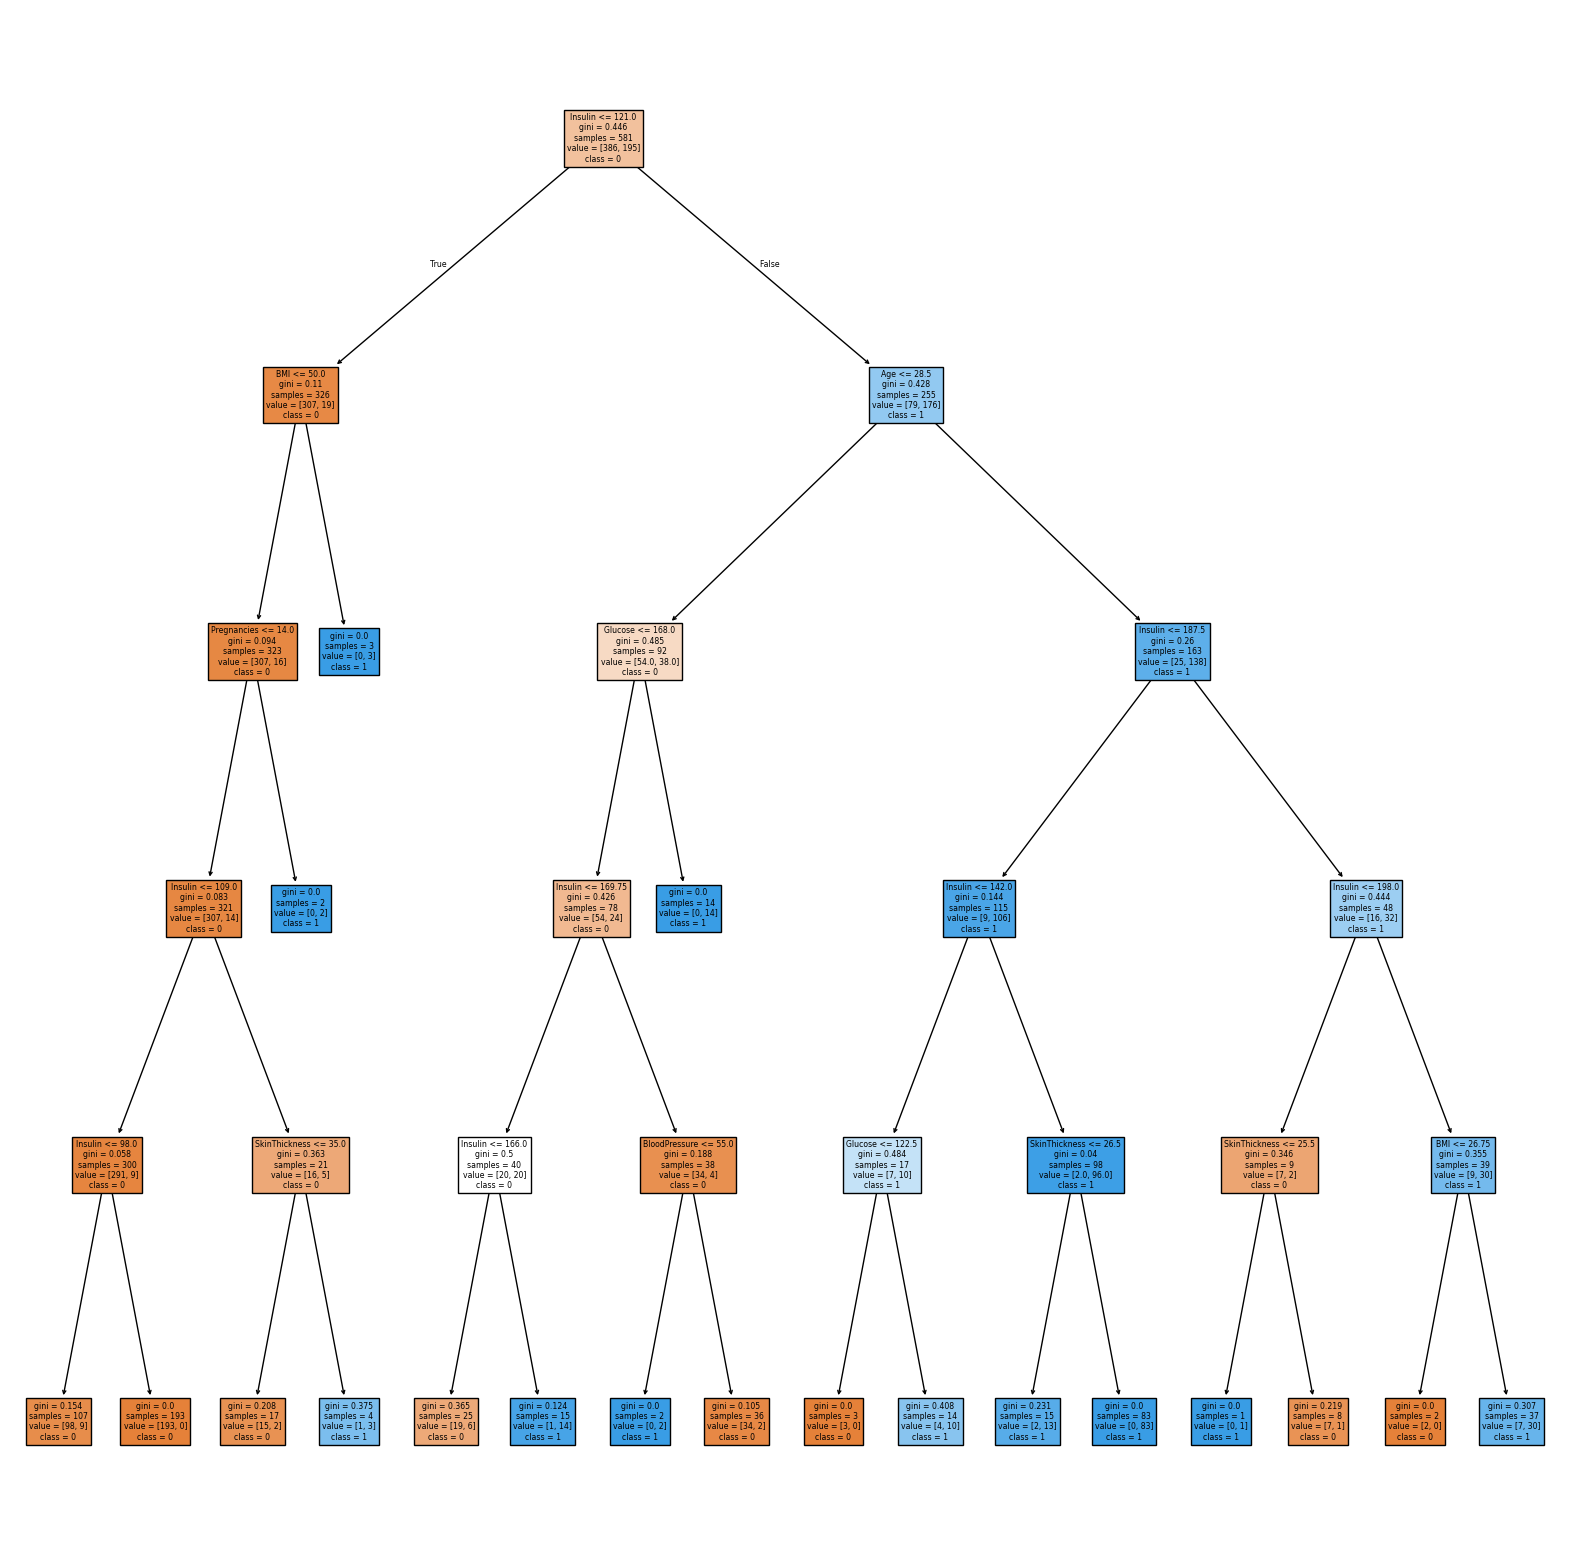

In [78]:
fig = plt.figure(figsize=(20,20))

tree.plot_tree(model, feature_names = list(X_train.columns), class_names = ["0", "1"], filled = True)

plt.show()

In [79]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

train_accuracy, test_accuracy


(0.9397590361445783, 0.8561643835616438)

## Observaciones

>Con los datos del train tenemos un 94% de precision, con los datos del test tenemos un 85% de precisión".
>
> Con un 85% de precisión podemos concluir que los datos son bastante buenos. mejorables seguramente con hiperparametros. 

In [80]:
hyperparams = { 'max_depth': [4, 5, 6, 7],
                'min_samples_split': [2, 3, 5, 8 , 10],
                'min_samples_leaf': [1, 2, 4, 10]}




grid_diabetes = GridSearchCV(DecisionTreeClassifier(random_state=18),
                    hyperparams,
                    cv=5,
                    n_jobs=-1,
                    verbose=1)
grid_diabetes.fit(X_train, y_train)

grid_diabetes.best_params_ 

Fitting 5 folds for each of 80 candidates, totalling 400 fits


{'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}

In [81]:
hyperparams = { 'max_depth': [5],
                'min_samples_split': [10, 11, 15, 30],
                'min_samples_leaf': [2, 3, 4]}




grid_diabetes = GridSearchCV(DecisionTreeClassifier(random_state=18),
                    hyperparams,
                    cv=5,
                    n_jobs=-1,
                    verbose=1)
grid_diabetes.fit(X_train, y_train)

grid_diabetes.best_params_ 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 15}

In [82]:
hyperparams = { 'max_depth': [5],
                'min_samples_split': [13, 14, 15, 20],
                'min_samples_leaf': [4, 5, 6]}




grid_diabetes = GridSearchCV(DecisionTreeClassifier(random_state=18),
                    hyperparams,
                    cv=5,
                    n_jobs=-1,
                    verbose=1)
grid_diabetes.fit(X_train, y_train)

grid_diabetes.best_params_ 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 14}

In [83]:
model = grid_diabetes.best_estimator_

y_pred_test = model.predict(X_test)

y_pred_train = model.predict(X_train)

accuracy_score(y_train, y_pred_train), accuracy_score(y_test, y_pred_test) 

(0.927710843373494, 0.8493150684931506)

## Observaciones

>Con los datos del train tenemos un 92% de precision, con los datos del test tenemos casi un 85% de precisión".
>
> Con hiperparametros lo que cambiamos fue que restamos el sobreajuste que antes era de 94% a 92%, aunque tenemos el mismo resultado en test podemos decir que al haber menos sobreajuste obtuvimos una mejora en el modelo. 